<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/Implementation_of_SAE_Plus_Plus_Reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [CELL 1 - Setup & Environment]
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import random

# Set deterministic seed for reproducible hierarchy extraction
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"SAE++ Execution Engine Initialized on: {device}")

SAE++ Execution Engine Initialized on: cuda


In [2]:
# [CELL 2 - Synthetic MLLM Vision Activations]
# Simulating dense representations from a vision encoder (e.g., Qwen3-VL / LLaVA ViT-L)

def generate_mllm_activations(num_samples=10000, d_act=1024, num_base_concepts=50):
    """
    Generates synthetic dense visual activations composed of overlapping base concepts.
    """
    # Create fixed orthogonal base concepts in the activation space
    base_concepts = torch.randn(num_base_concepts, d_act)
    base_concepts = F.normalize(base_concepts, dim=1)

    # Generate sparse coefficients to mix base concepts into realistic dense activations
    # Simulates visual patches containing 2-5 distinct visual features
    coefficients = torch.zeros(num_samples, num_base_concepts)
    for i in range(num_samples):
        active_idx = torch.randperm(num_base_concepts)[:random.randint(2, 5)]
        coefficients[i, active_idx] = torch.rand(len(active_idx)) * 2.0

    activations = coefficients @ base_concepts

    # Add ambient MLLM processing noise
    noise = torch.randn_like(activations) * 0.1
    activations = activations + noise
    return activations

d_act = 1024
dense_activations = generate_mllm_activations(num_samples=15000, d_act=d_act).to(device)
dataset = TensorDataset(dense_activations)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

print(f"Generated {len(dense_activations)} MLLM visual activations (Dimension: {d_act})")

Generated 15000 MLLM visual activations (Dimension: 1024)


In [3]:
# [CELL 3 - Top-K Sparse Autoencoder Architecture]

class TopKSparseAutoencoder(nn.Module):
    """
    Standard SAE using Top-K sparsity (avoids L1 shrinkage and dead latents).
    Used for both Level-1 (Flat Concepts) and Level-2 (Hierarchical Concepts).
    """
    def __init__(self, d_in, d_dict, k=32):
        super().__init__()
        self.d_in = d_in
        self.d_dict = d_dict
        self.k = k

        # Encoder
        self.encoder = nn.Linear(d_in, d_dict, bias=False)
        self.pre_bias = nn.Parameter(torch.zeros(d_in))
        self.latent_bias = nn.Parameter(torch.zeros(d_dict))

        # Decoder (Weights must be normalized during training)
        self.decoder = nn.Linear(d_dict, d_in, bias=False)

        # Initialize decoder weights with orthogonal rows, then normalize
        nn.init.orthogonal_(self.decoder.weight)
        self.normalize_decoder_()

    def normalize_decoder_(self):
        """Forces unit norm on decoder feature directions (columns)."""
        with torch.no_grad():
            norms = torch.norm(self.decoder.weight, dim=0, keepdim=True)
            self.decoder.weight.div_(norms + 1e-8)

    def forward(self, x):
        # Shift by pre-bias
        x_centered = x - self.pre_bias

        # Encode and compute Top-K
        pre_acts = self.encoder(x_centered) + self.latent_bias

        # Retain only top-k activations, zero out the rest
        top_k_vals, top_k_indices = torch.topk(pre_acts, self.k, dim=-1)
        sparse_acts = torch.zeros_like(pre_acts).scatter_(-1, top_k_indices, top_k_vals)
        sparse_acts = F.relu(sparse_acts) # Ensure non-negativity

        # Decode
        reconstruction = self.decoder(sparse_acts) + self.pre_bias

        return reconstruction, sparse_acts

print("Top-K SAE Architecture Defined.")

Top-K SAE Architecture Defined.


In [4]:
# [CELL 4 - Level 1 SAE Training on Visual Activations]

d_dict1 = 4096 # Expanding 1024 -> 4096
k_1 = 32       # 32 active concepts per patch
sae_l1 = TopKSparseAutoencoder(d_act, d_dict1, k=k_1).to(device)

optimizer_l1 = torch.optim.Adam(sae_l1.parameters(), lr=1e-3)

epochs_l1 = 15
print("Training Level-1 SAE (Extracting low-level visual concepts)...")

for epoch in range(1, epochs_l1 + 1):
    total_loss = 0.0
    for batch in dataloader:
        x = batch[0]

        optimizer_l1.zero_grad()
        reconstruction, sparse_acts = sae_l1(x)

        # MSE Reconstruction Loss (Top-K inherently enforces sparsity)
        loss = F.mse_loss(reconstruction, x)
        loss.backward()

        # Remove gradient information parallel to decoder features to stabilize directions
        with torch.no_grad():
            sae_l1.decoder.weight.grad -= (
                torch.sum(sae_l1.decoder.weight * sae_l1.decoder.weight.grad, dim=0, keepdim=True)
                * sae_l1.decoder.weight
            )

        optimizer_l1.step()
        sae_l1.normalize_decoder_() # Enforce norm constraint

        total_loss += loss.item()

    if epoch % 5 == 0 or epoch == 1:
        print(f"L1 Epoch {epoch:02d} | MSE Loss: {total_loss / len(dataloader):.4f}")

# Extract the learned decoder weights (Feature Directions)
with torch.no_grad():
    # Shape: [d_dict1, d_act] -> [4096, 1024]
    l1_feature_directions = sae_l1.decoder.weight.data.T

print(f"Level-1 Concepts Extracted. Feature matrix shape: {l1_feature_directions.shape}")

Training Level-1 SAE (Extracting low-level visual concepts)...
L1 Epoch 01 | MSE Loss: 0.0133
L1 Epoch 05 | MSE Loss: 0.0086
L1 Epoch 10 | MSE Loss: 0.0067
L1 Epoch 15 | MSE Loss: 0.0061
Level-1 Concepts Extracted. Feature matrix shape: torch.Size([4096, 1024])


In [5]:
# [CELL 5 - SAE++ Level 2 Training directly on L1 Decoder Weights]
# This isolates the core contribution of the paper: learning Concepts of Concepts.

d_dict2 = 256  # Grouping 4096 L1 concepts into 256 higher-level L2 concepts
k_2 = 4        # Each low-level concept maps to a few high-level families

sae_l2 = TopKSparseAutoencoder(d_act, d_dict2, k=k_2).to(device)
optimizer_l2 = torch.optim.Adam(sae_l2.parameters(), lr=1e-3)

# The training dataset for L2 is the weight matrix of L1
l2_dataset = TensorDataset(l1_feature_directions)
l2_dataloader = DataLoader(l2_dataset, batch_size=128, shuffle=True)

epochs_l2 = 30
print("Training Level-2 SAE (SAE++ Cascade on L1 Decoder Weights)...")

for epoch in range(1, epochs_l2 + 1):
    total_loss = 0.0
    for batch in l2_dataloader:
        w_l1_batch = batch[0] # The L1 feature directions

        optimizer_l2.zero_grad()
        reconstruction, sparse_acts = sae_l2(w_l1_batch)

        loss = F.mse_loss(reconstruction, w_l1_batch)
        loss.backward()

        with torch.no_grad():
             sae_l2.decoder.weight.grad -= (
                torch.sum(sae_l2.decoder.weight * sae_l2.decoder.weight.grad, dim=0, keepdim=True)
                * sae_l2.decoder.weight
            )

        optimizer_l2.step()
        sae_l2.normalize_decoder_()

        total_loss += loss.item()

    if epoch % 5 == 0 or epoch == 1:
        print(f"L2 Epoch {epoch:02d} | Reconstruction MSE Loss: {total_loss / len(l2_dataloader):.5f}")

Training Level-2 SAE (SAE++ Cascade on L1 Decoder Weights)...
L2 Epoch 01 | Reconstruction MSE Loss: 0.00098
L2 Epoch 05 | Reconstruction MSE Loss: 0.00094
L2 Epoch 10 | Reconstruction MSE Loss: 0.00090
L2 Epoch 15 | Reconstruction MSE Loss: 0.00088
L2 Epoch 20 | Reconstruction MSE Loss: 0.00088
L2 Epoch 25 | Reconstruction MSE Loss: 0.00087
L2 Epoch 30 | Reconstruction MSE Loss: 0.00087


In [6]:
# [CELL 6 - Validating Hierarchical Concept Coherence]

with torch.no_grad():
    # Pass all L1 feature directions through L2 encoder
    l2_reconstruction, l2_sparse_acts = sae_l2(l1_feature_directions)

    # Calculate how well L2 can reconstruct the L1 concept space
    mse_eval = F.mse_loss(l2_reconstruction, l1_feature_directions).item()
    variance_explained = 1.0 - (torch.var(l1_feature_directions - l2_reconstruction) / torch.var(l1_feature_directions))

    print("=" * 50)
    print("SAE++ HIERARCHICAL EVALUATION METRICS")
    print("=" * 50)
    print(f"L2 Reconstruction MSE on L1 Space : {mse_eval:.5f}")
    print(f"Variance Explained by L2 Concepts : {variance_explained * 100:.2f}%")

    # Analyze group sizes (How many L1 concepts belong to each L2 concept?)
    # A non-zero activation implies membership
    memberships = (l2_sparse_acts > 0).float()
    group_sizes = memberships.sum(dim=0) # Sum across L1 concepts for each L2 concept

    active_l2_concepts = (group_sizes > 0).sum().item()
    print(f"Active L2 Concept Families        : {active_l2_concepts} / {d_dict2}")
    print(f"Average L1 Concepts per L2 Group  : {group_sizes[group_sizes > 0].mean().item():.1f}")
    print("=" * 50)

SAE++ HIERARCHICAL EVALUATION METRICS
L2 Reconstruction MSE on L1 Space : 0.00086
Variance Explained by L2 Concepts : 11.56%
Active L2 Concept Families        : 256 / 256
Average L1 Concepts per L2 Group  : 64.0


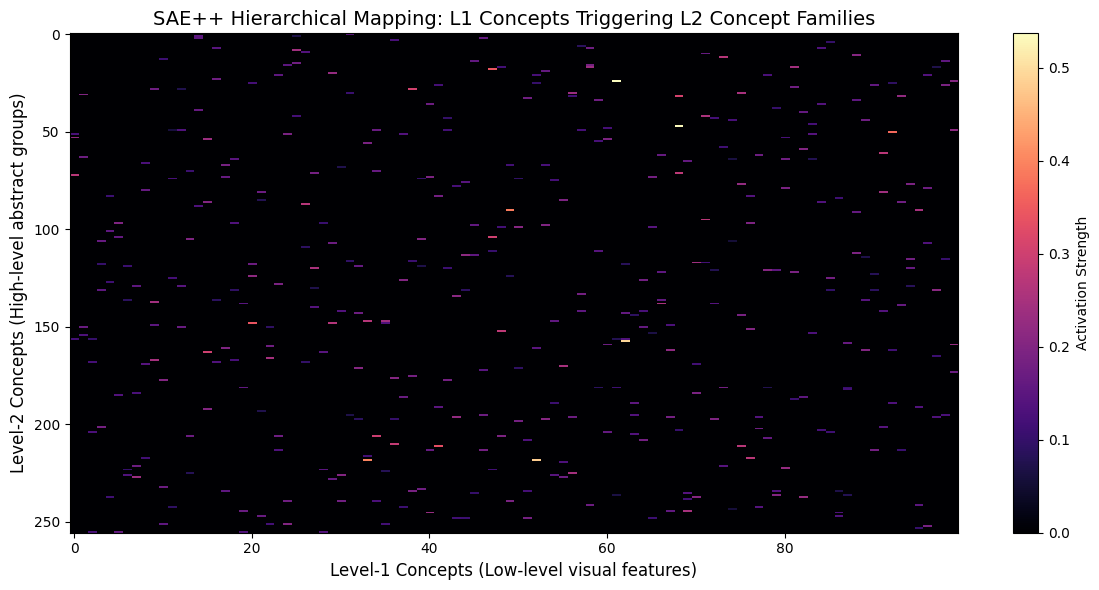

In [7]:
# [CELL 7 - Qualitative Analysis Plot]

# Visualize the mapping between the first 100 L1 concepts and their corresponding L2 activations
mapping_subset = l2_sparse_acts[:100, :].cpu().numpy()

plt.figure(figsize=(12, 6))
plt.imshow(mapping_subset.T, aspect='auto', cmap='magma', interpolation='none')
plt.title("SAE++ Hierarchical Mapping: L1 Concepts Triggering L2 Concept Families", fontsize=14)
plt.xlabel("Level-1 Concepts (Low-level visual features)", fontsize=12)
plt.ylabel("Level-2 Concepts (High-level abstract groups)", fontsize=12)
plt.colorbar(label="Activation Strength")
plt.tight_layout()
plt.show()